In [1]:
import numpy as np
import pandas as pd
import os
from collections import defaultdict

In [2]:
def _parse_npz(path):
    loaded_data_file = np.load(path)

    # 2. Reconstruct the dictionary
    reconstructed_data = {}
    for full_key in loaded_data_file.files:
        # Split the key (e.g., 'A/X' -> ('A', 'X'))
        outer_key, inner_key = full_key.split('/')

        # Get the array
        array = loaded_data_file[full_key]

        # Initialize the inner dict if it doesn't exist
        if outer_key not in reconstructed_data:
            reconstructed_data[outer_key] = {}

        # Store the array
        reconstructed_data[outer_key][inner_key] = array

    print("Data successfully loaded and reconstructed.")
    return reconstructed_data

def parse_results(path):
    return _parse_npz(os.path.join(path, 'accuracy_results.npz')), _parse_npz(os.path.join(path, 'full_results.npz'))

In [3]:
def dict_to_pandas(data):
    records = []

    for outer_key, inner_dict in data.items():
        # Initialize a temporary dictionary for the current record (row)
        record = {'test_mode': outer_key} # Use the outer key as a unique identifier

        for inner_key, np_array in inner_dict.items():
            # Crucial step: Extract the scalar value from the one-element array.
            # np_array.item() is the most robust way to get the scalar.
            scalar_value = np_array.item()
            
            # Add the inner key/value pair to the record
            record[inner_key] = scalar_value
        
        # Add the completed record to the list
        records.append(record)
    
    df = pd.DataFrame(records)
    df = df.set_index('test_mode')
    return df

In [27]:
# path = 'experiments/exp2_full2' 
path = 'experiments/exp3'
accuracy_results, full_results = parse_results(path)

Data successfully loaded and reconstructed.
Data successfully loaded and reconstructed.


In [28]:
accuracy_results_pd = dict_to_pandas(accuracy_results)
display(accuracy_results_pd)

,train:random,train:int,train:upper,train:lower,train:ortho,train:random_eps
test_mode,,,,,,
test:random,0.6248,0.4820,0.4030,0.4096,0.4266,0.6134
test:int,0.5776,0.6916,0.4036,0.4068,0.4026,0.5808
test:upper,0.5712,0.4650,0.8900,0.6746,0.4300,0.5446
test:lower,0.5198,0.4550,0.4884,0.8780,0.4090,0.5096
test:ortho,0.8076,0.5260,0.4194,0.4574,1.0000,0.8758
test:random_eps,0.5128,0.4294,0.2824,0.2410,0.3814,0.5958


In [29]:
def _compute_accuracy_from_cm(matrix):
    return np.trace(matrix) / np.sum(matrix)

def _compute_accuracies(full_results):
    accuracies = defaultdict(dict)
    for outer_k, v in full_results.items():
        for inner_k, matrix in v.items():
            accuracies[outer_k][inner_k] = _compute_accuracy_from_cm(matrix[1:,1:])
    df = dict_to_pandas(accuracies)
    return df

In [30]:
accuracies = _compute_accuracies(full_results)

In [31]:
with pd.option_context('display.precision', 3):
    display(accuracies)

,train:random,train:int,train:upper,train:lower,train:ortho,train:random_eps
test_mode,,,,,,
test:random,0.531,0.353,0.254,0.262,0.283,0.520
test:int,0.472,0.615,0.255,0.259,0.253,0.476
test:upper,0.465,0.334,0.865,0.594,0.290,0.439
test:lower,0.400,0.319,0.361,0.848,0.262,0.389
test:ortho,0.759,0.409,0.274,0.322,1.000,0.851
test:random_eps,0.521,0.352,0.259,0.271,0.289,0.537


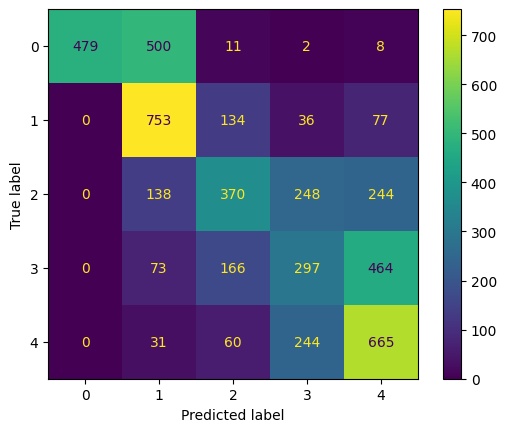

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = full_results['test:random_eps']['train:random']
ConfusionMatrixDisplay(cm).plot()

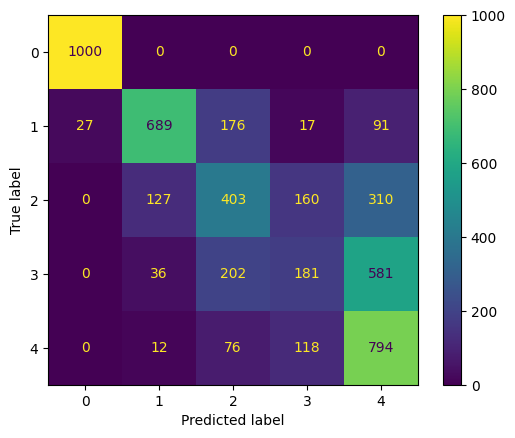

In [33]:
cm = full_results['test:random']['train:random_eps']
ConfusionMatrixDisplay(cm).plot()